# 01 — Exploratory Data Analysis
**Project:** Mental Health in Tech Survey (OSMI)  
**Goal:** Load, clean, and explore the dataset before visualisation and modelling.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load the dataset

In [3]:
# Make sure survey.csv is in the same folder as this notebook
# Download from: https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey

df = pd.read_csv('survey.csv')

print(f'Shape: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Shape: 1259 rows, 27 columns


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


## 3. First look — structure and types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [5]:
# See all column names clearly
for col in df.columns:
    print(col)

Timestamp
Age
Gender
Country
state
self_employed
family_history
treatment
work_interfere
no_employees
remote_work
tech_company
benefits
care_options
wellness_program
seek_help
anonymity
leave
mental_health_consequence
phys_health_consequence
coworkers
supervisor
mental_health_interview
phys_health_interview
mental_vs_physical
obs_consequence
comments


## 4. Missing values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'Missing count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing count'] > 0].sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(missing_df)}')
missing_df

Columns with missing values: 4


,Missing count,Missing %
comments,1095,87.0
state,515,40.9
work_interfere,264,21.0
self_employed,18,1.4


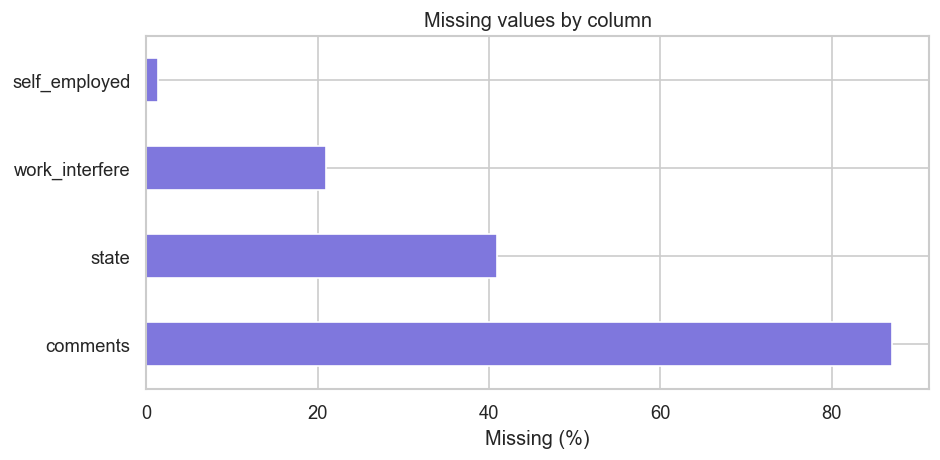

In [7]:
# Visualise missing values
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    missing_df['Missing %'].plot(kind='barh', ax=ax, color='#7F77DD')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing values by column')
    plt.tight_layout()
    plt.show()

## 5. Data cleaning

In [8]:
df_clean = df.copy()

# --- Age: remove outliers (keep 18-75 only) ---
print(f'Age range before: {df_clean["Age"].min()} to {df_clean["Age"].max()}')
df_clean = df_clean[(df_clean['Age'] >= 18) & (df_clean['Age'] <= 75)]
print(f'Age range after:  {df_clean["Age"].min()} to {df_clean["Age"].max()}')

Age range before: -1726 to 99999999999
Age range after:  18 to 72


In [9]:
# --- Gender: standardise to 3 categories ---
print('Unique gender values before cleaning:')
print(df_clean['Gender'].value_counts().head(20))

Unique gender values before cleaning:
Male                        612
male                        204
Female                      121
M                           116
female                       62
F                            38
m                            34
f                            15
Make                          4
Woman                         3
Male                          3
Man                           2
Female (trans)                2
Cis Male                      2
Female                        2
Enby                          1
Mail                          1
Guy (-ish) ^_^                1
male leaning androgynous      1
woman                         1
Name: Gender, dtype: int64


In [10]:
def clean_gender(g):
    g = str(g).strip().lower()
    if g in ['male', 'm', 'man', 'cis male', 'cis man', 'male (cis)', 'malr', 'mail', 'msle', 'make']:
        return 'Male'
    elif g in ['female', 'f', 'woman', 'cis female', 'cis woman', 'female (cis)', 'femake', 'femail']:
        return 'Female'
    else:
        return 'Other'

df_clean['Gender'] = df_clean['Gender'].apply(clean_gender)

print('Gender after cleaning:')
print(df_clean['Gender'].value_counts())

Gender after cleaning:
Male      983
Female    246
Other      22
Name: Gender, dtype: int64


In [11]:
# --- Country: keep top countries, group rest as 'Other' ---
top_countries = df_clean['Country'].value_counts().nlargest(10).index
df_clean['Country_grouped'] = df_clean['Country'].apply(
    lambda x: x if x in top_countries else 'Other'
)

print('Top countries:')
print(df_clean['Country_grouped'].value_counts())

Top countries:
United States     746
United Kingdom    184
Other              98
Canada             72
Germany            45
Netherlands        27
Ireland            27
Australia          21
France             13
India              10
New Zealand         8
Name: Country_grouped, dtype: int64


In [12]:
# --- self_employed: fill missing with 'No' (most common) ---
df_clean['self_employed'] = df_clean['self_employed'].fillna('No')

# --- work_interfere: fill missing with 'Don\'t know' ---
df_clean['work_interfere'] = df_clean['work_interfere'].fillna("Don't know")

print('Missing values remaining:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values remaining:
state        513
comments    1090
dtype: int64


In [13]:
# --- Final cleaned shape ---
print(f'Original shape: {df.shape}')
print(f'Cleaned shape:  {df_clean.shape}')

Original shape: (1259, 27)
Cleaned shape:  (1251, 28)


## 6. Distribution of key variables

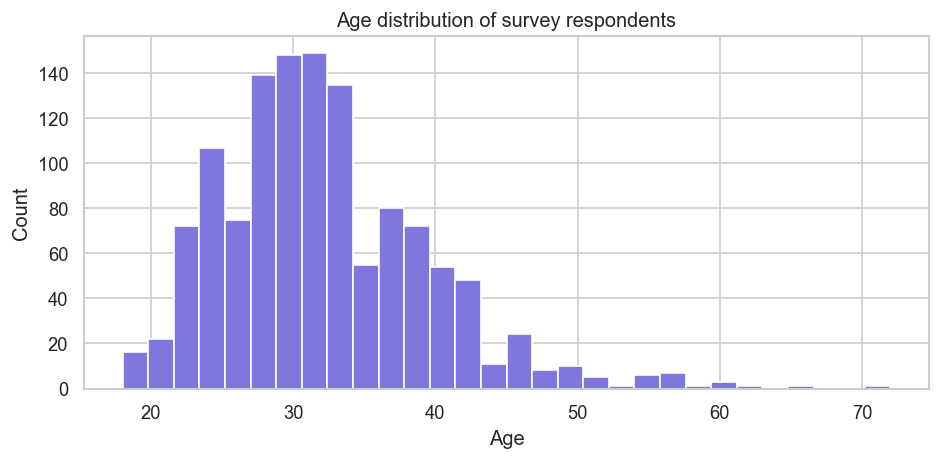

count    1251.0
mean       32.1
std         7.3
min        18.0
25%        27.0
50%        31.0
75%        36.0
max        72.0
Name: Age, dtype: float64


In [14]:
# Age distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_clean['Age'], bins=30, color='#7F77DD', edgecolor='white')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.set_title('Age distribution of survey respondents')
plt.tight_layout()
plt.show()

print(df_clean['Age'].describe().round(1))

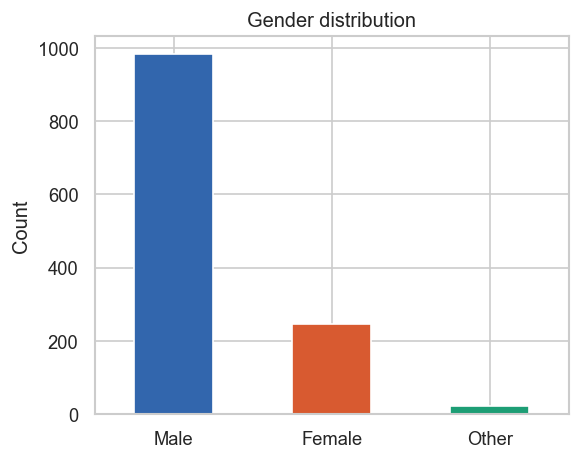

In [15]:
# Gender distribution
gender_counts = df_clean['Gender'].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
gender_counts.plot(kind='bar', ax=ax, color=['#3266ad', '#D85A30', '#1D9E75'], edgecolor='white')
ax.set_title('Gender distribution')
ax.set_ylabel('Count')
ax.set_xticklabels(gender_counts.index, rotation=0)
plt.tight_layout()
plt.show()

Treatment-seeking breakdown:
Yes    632
No     619
Name: treatment, dtype: int64

% who sought treatment: 50.5%


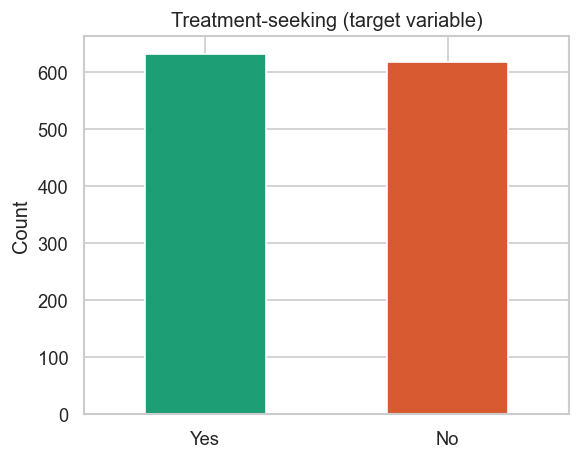

In [16]:
# Treatment-seeking (target variable)
treatment_counts = df_clean['treatment'].value_counts()
print('Treatment-seeking breakdown:')
print(treatment_counts)
print(f'\n% who sought treatment: {(treatment_counts["Yes"] / len(df_clean) * 100):.1f}%')

fig, ax = plt.subplots(figsize=(5, 4))
treatment_counts.plot(kind='bar', ax=ax, color=['#1D9E75', '#D85A30'], edgecolor='white')
ax.set_title('Treatment-seeking (target variable)')
ax.set_ylabel('Count')
ax.set_xticklabels(['Yes', 'No'], rotation=0)
plt.tight_layout()
plt.show()

## 7. Key variable value counts (categorical overview)

In [17]:
# Check all key categorical columns
key_cols = [
    'self_employed', 'family_history', 'work_interfere',
    'remote_work', 'benefits', 'care_options',
    'wellness_program', 'seek_help', 'anonymity',
    'leave', 'mental_health_consequence', 'phys_health_consequence'
]

for col in key_cols:
    if col in df_clean.columns:
        print(f'\n--- {col} ---')
        print(df_clean[col].value_counts())


--- self_employed ---
No     1109
Yes     142
Name: self_employed, dtype: int64

--- family_history ---
No     762
Yes    489
Name: family_history, dtype: int64

--- work_interfere ---
Sometimes     464
Don't know    262
Never         212
Rarely        173
Often         140
Name: work_interfere, dtype: int64

--- remote_work ---
No     880
Yes    371
Name: remote_work, dtype: int64

--- benefits ---
Yes           473
Don't know    407
No            371
Name: benefits, dtype: int64

--- care_options ---
No          499
Yes         439
Not sure    313
Name: care_options, dtype: int64

--- wellness_program ---
No            837
Yes           227
Don't know    187
Name: wellness_program, dtype: int64

--- seek_help ---
No            641
Don't know    363
Yes           247
Name: seek_help, dtype: int64

--- anonymity ---
Don't know    815
Yes           372
No             64
Name: anonymity, dtype: int64

--- leave ---
Don't know            561
Somewhat easy         265
Very easy           

## 8. Correlation heatmap (encoded)

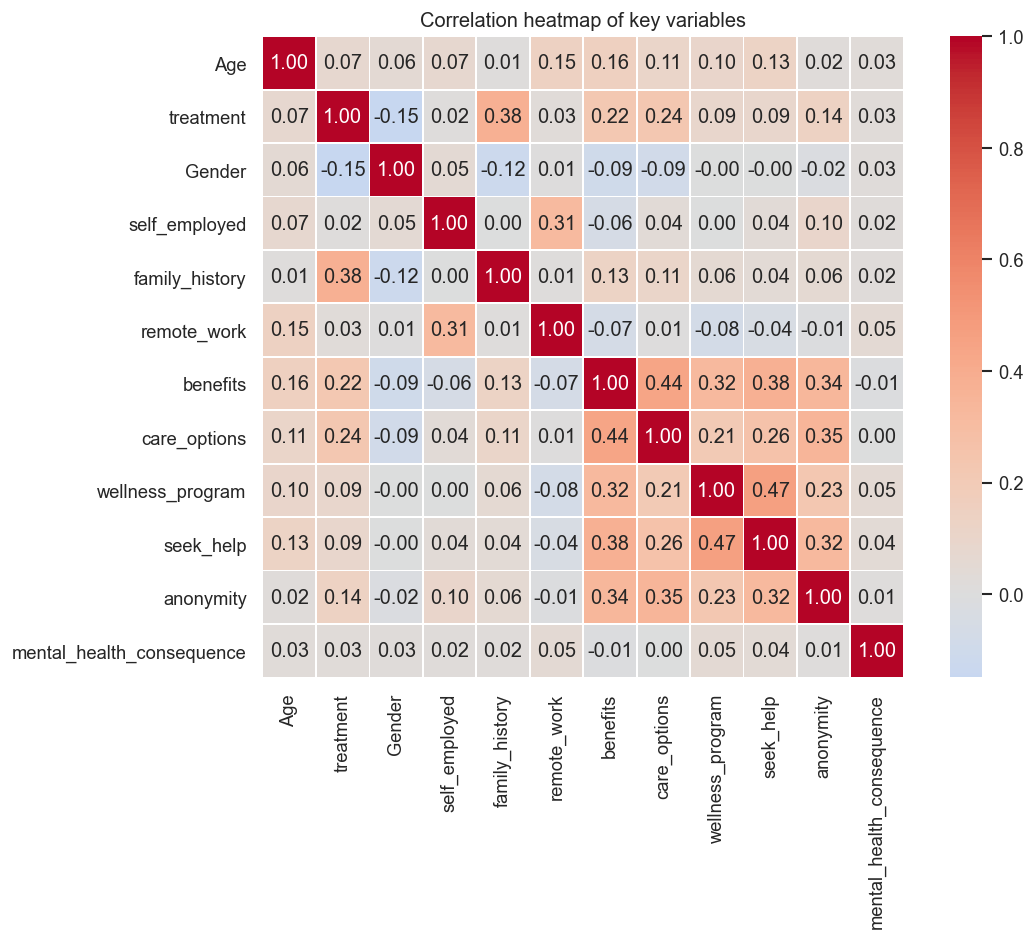

In [18]:
from sklearn.preprocessing import LabelEncoder

encode_cols = [
    'treatment', 'Gender', 'self_employed', 'family_history',
    'remote_work', 'benefits', 'care_options', 'wellness_program',
    'seek_help', 'anonymity', 'mental_health_consequence'
]

df_encoded = df_clean.copy()
le = LabelEncoder()

for col in encode_cols:
    if col in df_encoded.columns:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Include Age
corr_cols = ['Age'] + [c for c in encode_cols if c in df_encoded.columns]
corr_matrix = df_encoded[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, ax=ax, linewidths=0.5, square=True
)
ax.set_title('Correlation heatmap of key variables')
plt.tight_layout()
plt.show()

## 9. Save cleaned dataset

In [20]:
df_clean.to_csv('survey_clean.csv', index=False)
print('Cleaned dataset saved to survey_clean.csv')
print(f'Final shape: {df_clean.shape}')

Cleaned dataset saved to survey_clean.csv
Final shape: (1251, 28)


## 10. Summary of findings

After cleaning and exploring the OSMI dataset:

- **Respondents:** ~1,250 after removing invalid ages
- **Gender:** Majority male (~80%), followed by female (~15%), other (~5%)
- **Treatment:** About 50% of respondents sought mental health treatment
- **Key variables for analysis:** `family_history`, `work_interfere`, `benefits`, `remote_work`
- **Next step:** `02_viz.ipynb` — visualise how these variables relate to treatment-seeking